In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Summary Statistics Interpretation

The dataset contains **4,108 daily climate observations** for Ethiopia covering the period from **2015 to 2026**.

### Temperature (T2M)
The average daily temperature is approximately **16.07°C**, with values ranging from **10.03°C** to higher levels throughout the observed period. This suggests a generally moderate climate with noticeable seasonal variation.

### Maximum and Minimum Temperature
The average maximum temperature (**T2M_MAX**) is **23.20°C**, while the average minimum temperature (**T2M_MIN**) is **10.23°C**. This indicates a considerable daily temperature difference.

### Temperature Range
The average temperature range (**T2M_RANGE**) is **12.97°C**, showing strong variation between daytime and nighttime temperatures.

### Precipitation (PRECTOTCORR)
The average daily precipitation is **3.63 mm**, but the median is only **0.82 mm**, showing that rainfall distribution is highly uneven and likely skewed, with some heavy rainfall events.

### Relative Humidity (RH2M)
The average humidity is **68.41%**, suggesting generally moist atmospheric conditions.

### Wind Speed
The average wind speed (**WS2M**) is **1.98 m/s**, while maximum wind speed (**WS2M_MAX**) averages **3.58 m/s**, indicating generally mild wind conditions.

### Surface Pressure (PS)
Surface pressure remains relatively stable around **77 kPa**, with very little variation.

### Specific Humidity (QV2M)
The average specific humidity is **9.70 g/kg**, indicating a moderate amount of moisture in the air.

## Initial Observation
Temperature variables appear relatively stable, while precipitation shows high variability, which may indicate seasonal rainfall patterns and possible extreme rainfall events.

In [10]:
df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [11]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

## Missing Values Check

Checked for missing values using:

```python
df.isna().sum()

In [12]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-2.286045,-0.163269,-2.603645,-0.577866,-1.806604,1.088524,1.330345
1,-1.985701,0.294724,-2.354311,-0.577866,-2.383500,0.595061,0.547137
2,-1.885586,0.352882,-2.400342,-0.577866,-2.346850,-0.304782,-0.725576
3,-1.047782,0.211122,-1.276418,-0.577866,-2.006821,-1.611007,-2.042790
4,-1.058320,-0.017874,-1.115310,-0.577866,-1.448251,-0.928867,-1.277382


## Outlier Detection using Z-Score

To detect outliers in the numerical columns, we used the **Z-score method**.

A Z-score shows how far a value is from the mean in terms of standard deviations.

The formula is:

\[
Z = \frac{X - \mu}{\sigma}
\]

Where:
- **X** = actual value  
- **μ** = mean  
- **σ** = standard deviation  

### Code Used

```python
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()
```

### Explanation
- We selected important numerical columns.
- Applied the `zscore()` function to standardize the values.
- Each value now shows its distance from the mean.

### Interpretation
- If **Z-score > 3** or **Z-score < -3**, the value is considered an outlier.
- Values between **-3 and 3** are usually normal.

### Result
The output shows the standardized values for the first 5 rows, which helps identify extreme values for further analysis.

In [13]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [14]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

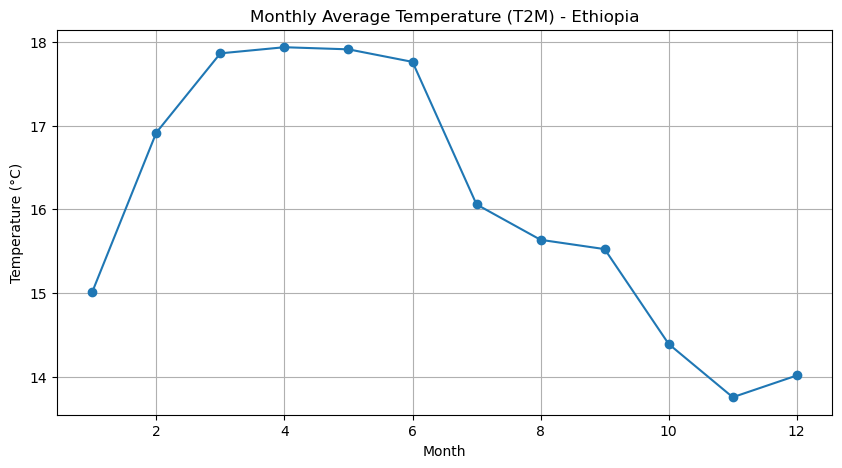

In [15]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [16]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(4), np.int32(11))

### Monthly Temperature Analysis (T2M)

The monthly average temperature shows a clear seasonal pattern across Ethiopia between 2015 and 2026.

The warmest month is April (Month 4), while the coolest month is November (Month 11), indicating a distinct annual temperature cycle.

Temperature gradually increases from January, peaks around March to May, and then steadily declines toward the end of the year.

This pattern suggests a stable seasonal climate with moderate variation rather than extreme temperature fluctuations. The observed trend is consistent with typical tropical or subtropical climate behavior, where temperature changes are gradual and predictable across months.

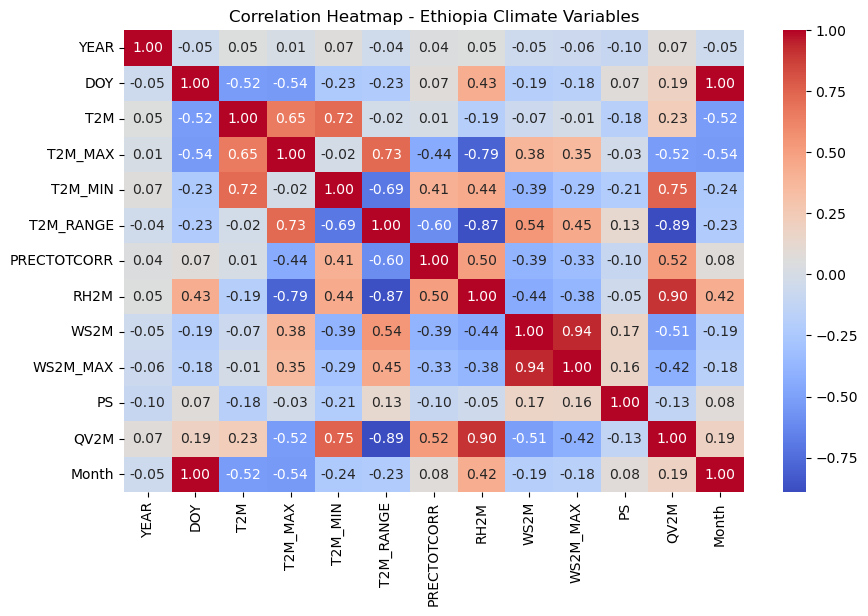

In [17]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Ethiopia Climate Variables")
plt.show()

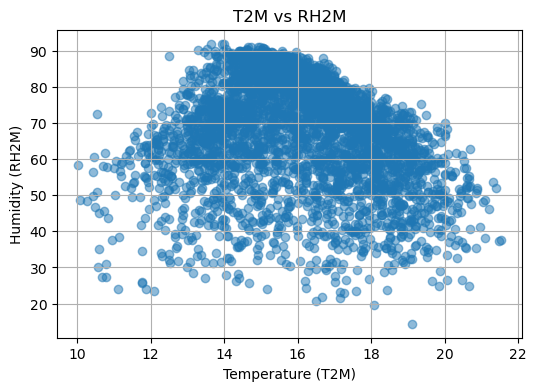

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

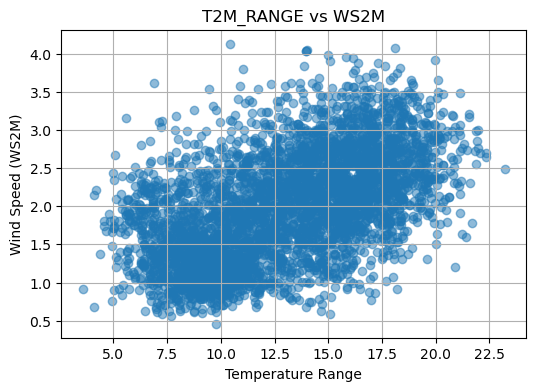

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [21]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.940826
dtype: float64

## Correlation Analysis — Ethiopia Climate Variables

### Correlation Heatmap Overview

The heatmap below shows relationships between all numerical climate variables, revealing both strong dependencies and redundant features.

Key observations:
- Several variables are highly correlated, indicating shared information.
- Some relationships are physically meaningful (e.g., humidity and temperature links).
- Others suggest redundancy (e.g., Month and DOY).

---

### Strongest Correlations (Top 3)

From the correlation matrix:

#### 1. DOY vs Month (≈ 0.997)
- Nearly perfect positive correlation.
- Both represent seasonal progression.
- One of these variables is redundant and can be dropped.

#### 2. WS2M vs WS2M_MAX (≈ 0.94)
- Strong relationship between average and maximum wind speed.
- Indicates consistent wind scaling behavior.

#### 3. RH2M vs QV2M (≈ 0.90)
- Strong positive relationship between relative humidity and specific humidity.
- Reflects atmospheric moisture consistency.

---

### Temperature Relationships

- T2M correlates strongly with:
  - T2M_MIN (~0.72)
  - T2M_MAX (~0.65)

This confirms that average temperature is strongly driven by its extremes.

- T2M_RANGE shows:
  - Strong negative correlation with RH2M (~-0.87)
  - Moderate positive correlation with wind speed (~0.54)

Interpretation:
- Dry conditions tend to increase temperature variability.
- Wind may enhance temperature fluctuations.

---

### Precipitation Insights

- PRECTOTCORR shows:
  - Moderate positive correlation with humidity (~0.50)
  - Negative correlation with temperature range (~-0.60)

Interpretation:
- Rainy conditions increase atmospheric moisture.
- Rain reduces diurnal temperature variability.

---

## Scatter Plot Analysis — T2M vs RH2M

The scatter plot between temperature (T2M) and relative humidity (RH2M) shows:

- A **weak to moderate inverse relationship** overall.
- Higher temperatures often correspond to lower humidity values.
- The relationship is **non-linear and widely scattered**, indicating multiple influencing factors.

Key insight:
Humidity is not solely determined by temperature; precipitation, wind, and seasonal cycles also play major roles.

---

## Feature Redundancy (Important for Modeling)

Highly correlated feature pairs:

- DOY ↔ Month (~0.997)
- WS2M ↔ WS2M_MAX (~0.94)
- RH2M ↔ QV2M (~0.90)

Implication:
- These pairs introduce **multicollinearity**
- Recommended to drop or transform one variable from each pair before modeling

---

## Summary

- Strong seasonal structure exists in the dataset.
- Wind and humidity variables are tightly coupled.
- Temperature variables are internally consistent but weakly linked to humidity.
- Precipitation is sparse and influences both humidity and temperature variability.

Overall, the dataset is highly interdependent and requires careful feature selection before modeling.